In [23]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Allow importing eval.metrics from the scripts/ directory
sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from eval.metrics import read_traj_metrics  # available for instance-level analysis

In [24]:
# ── Evaluation directories ────────────────────────────────────────────────────
# Set EVAL_DIR_B = None  → single-eval report for EVAL_DIR_A only.
# Set EVAL_DIR_B to a path → side-by-side comparison (A = original, B = metamorphic).

# usually, original
EVAL_DIR_A = "/Users/vartiukhov/dev/studies/hse/thesis/thesis-metamorphic-eval/results/eval_3_easy_benchmarks"
# usually, metamorphic
EVAL_DIR_B = None   # change to None or another path

LABEL_A = "Original"
LABEL_B = "Metamorphic"

# ── Plot styling ──────────────────────────────────────────────────────────────
COLOR_A    = "#4C72B0"   # blue  — eval A
COLOR_B    = "#DD8452"   # orange — eval B
ALPHA_BAND = 0.15        # opacity of ±std shaded bands

plt.rcParams.update({
    "figure.dpi":        120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
    "axes.titlesize":    11,
    "axes.labelsize":    9,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
})

print(f"Mode: {'comparison' if EVAL_DIR_B is not None else 'single'}")
print(f"  A = {Path(EVAL_DIR_A).name!r}  ({LABEL_A})")
if EVAL_DIR_B is not None:
    print(f"  B = {Path(EVAL_DIR_B).name!r}  ({LABEL_B})")

Mode: single
  A = 'eval_3_easy_benchmarks'  (Original)


In [25]:
# ─── Data loading ─────────────────────────────────────────────────────────────

def load_metrics(dirpath, filename: str = "metrics_summary.json") -> dict:
    """Load metrics_summary.json from an eval results directory."""
    path = Path(dirpath) / filename
    if not path.exists():
        raise FileNotFoundError(f"metrics_summary.json not found in: {dirpath}")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def validate_metrics(metrics: dict, label: str) -> list:
    """
    Return a list of warning strings for data quality issues:
    - Runs where total_instances < n_instances_per_run (incomplete eval run, pass rate may be inflated)
    - Runs with n_missing > 0 in agent metrics (missing .traj files)
    """
    issues = []
    expected = metrics.get("n_instances_per_run")

    for run in metrics.get("per_run", []):
        run_num = run["run_number"]
        ev = run.get("evaluation")
        if ev and expected is not None and ev["total_instances"] < expected:
            issues.append(
                f"[{label}] Run {run_num}: only {ev['total_instances']} of "
                f"{expected} instances were evaluated — pass rate may be inflated."
            )
        ag = run.get("agent")
        if ag and ag.get("n_missing", 0) > 0:
            issues.append(
                f"[{label}] Run {run_num}: {ag['n_missing']} trajectory file(s) missing "
                "— agent metrics are incomplete."
            )
    return issues


def get_per_run_pass_rates(metrics: dict) -> list:
    """Extract per_run[i].evaluation.pass_rate values in run order."""
    return [
        run["evaluation"]["pass_rate"]
        for run in metrics["per_run"]
        if run.get("evaluation") is not None
    ]


def get_per_run_agent_field(metrics: dict, field: str) -> list:
    """Extract per_run[i].agent.{field}.avg values in run order."""
    return [
        run["agent"][field]["avg"]
        for run in metrics["per_run"]
        if run.get("agent") and field in run["agent"]
    ]


def get_run_numbers(metrics: dict) -> list:
    """Return the run_number list from per_run."""
    return [r["run_number"] for r in metrics["per_run"]]

In [26]:
# ─── Single-eval plots ────────────────────────────────────────────────────────

def plot_pass_rate_distribution(
    metrics: dict,
    label: str,
    color: str = COLOR_A,
    ax=None,
) -> None:
    """
    Bar chart of per-run pass rates with avg ± std band.
    Anomalous runs (total_instances < n_instances_per_run) are marked with '*'.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 3.5))

    expected   = metrics.get("n_instances_per_run")
    pr         = metrics.get("pass_rate", {})
    avg        = pr.get("avg")
    std        = pr.get("std")
    per_run    = pr.get("per_run", [])
    run_nums   = [r["run_number"] for r in per_run]
    pass_rates = [r["pass_rate"]  for r in per_run]
    totals     = [r["total"]      for r in per_run]

    xs = np.arange(len(run_nums))
    ax.bar(xs, pass_rates, color=color, alpha=0.75, width=0.6, zorder=3)

    for i, (rate, total) in enumerate(zip(pass_rates, totals)):
        if expected is not None and total < expected:
            ax.text(xs[i], rate + 1.5, "*", ha="center", color="crimson", fontsize=13, zorder=5)

    if avg is not None:
        ax.axhline(avg, color=color, linewidth=1.5, linestyle="--", label=f"avg = {avg:.1f}%")
    if avg is not None and std is not None:
        ax.axhspan(avg - std, avg + std, color=color, alpha=ALPHA_BAND, label=f"±std ({std:.1f}%)")

    ax.set_xticks(xs)
    ax.set_xticklabels([f"R{n}" for n in run_nums])
    ax.set_ylim(0, 110)
    ax.set_ylabel("Pass rate (%)")
    ax.set_title(f"{label} — pass rate per run")
    ax.legend(fontsize=8)

    n_inst = metrics.get("n_instances_per_run", "?")
    ax.text(0.01, 0.97, f"M = {n_inst} instances/run  |  * = incomplete eval run",
            transform=ax.transAxes, va="top", fontsize=7, color="gray")


def plot_agent_metrics_per_run(
    metrics: dict,
    label: str,
    color: str = COLOR_A,
    fields: tuple = ("instance_cost", "tokens_sent", "api_calls"),
    titles: tuple = ("Instance cost (USD)", "Tokens sent", "API calls"),
) -> None:
    """
    1×N subplot row: per-run line chart for each agent metric field.
    Shaded band shows run_variability ±std range around the overall avg.

    Note: instance_cost (not total_cost) is used as the primary cost metric.
    instance_cost is the marginal cost for a single instance's API calls,
    independent of session ordering. total_cost accumulates context across
    multiple instances and is not comparable across different session sizes.
    """
    fig, axes = plt.subplots(1, len(fields), figsize=(12, 3.5))
    fig.suptitle(f"{label} — agent metrics per run", fontsize=11, y=1.02)

    run_nums = get_run_numbers(metrics)
    var      = metrics.get("run_variability", {})
    xs       = np.arange(len(run_nums))

    for ax, field, title in zip(axes, fields, titles):
        values  = get_per_run_agent_field(metrics, field)
        fv      = var.get(field, {})
        avg_val = fv.get("avg_of_run_avgs")
        std_val = fv.get("std_of_run_avgs")

        ax.plot(xs, values, marker="o", color=color, linewidth=1.5, markersize=5, zorder=3)
        if avg_val is not None:
            ax.axhline(avg_val, color=color, linestyle="--", linewidth=1, alpha=0.6)
        if avg_val is not None and std_val is not None:
            ax.axhspan(avg_val - std_val, avg_val + std_val, color=color, alpha=ALPHA_BAND)

        ax.set_xticks(xs)
        ax.set_xticklabels([f"R{n}" for n in run_nums])
        ax.set_title(title)

    plt.tight_layout()


def plot_cost_vs_tokens_scatter(metrics: dict, label: str, color: str = COLOR_A, ax=None) -> None:
    """
    Scatter: avg tokens_sent vs avg instance_cost per run, annotated with run numbers.
    Useful for confirming linear cost scaling and spotting outlier (expensive/stuck) runs.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    run_nums = get_run_numbers(metrics)
    costs    = get_per_run_agent_field(metrics, "instance_cost")
    tokens   = get_per_run_agent_field(metrics, "tokens_sent")

    ax.scatter(tokens, costs, color=color, s=60, zorder=3, alpha=0.85)
    for rn, x, y in zip(run_nums, tokens, costs):
        ax.annotate(f"R{rn}", (x, y), textcoords="offset points",
                    xytext=(5, 3), fontsize=7, color="gray")

    ax.set_xlabel("Avg tokens sent")
    ax.set_ylabel("Avg instance cost (USD)")
    ax.set_title(f"{label} — cost vs. tokens per run")


def print_summary_table(metrics: dict, label: str) -> None:
    """Print headline numbers as a formatted text summary."""
    pr   = metrics.get("pass_rate", {})
    pool = metrics.get("pooled", {})
    n_r  = metrics.get("n_runs", "?")
    n_i  = metrics.get("n_instances_per_run", "?")

    avg_pr = pr.get("avg")
    std_pr = pr.get("std")
    ic     = pool.get("instance_cost", {})
    ts     = pool.get("tokens_sent", {})
    ac     = pool.get("api_calls", {})

    print(f"{'─'*50}")
    print(f"  {label}  ({n_r} runs × {n_i} instances)")
    print(f"{'─'*50}")
    if avg_pr is not None:
        std_s = f"± {std_pr:.1f}" if std_pr is not None else ""
        print(f"  Pass rate      {avg_pr:>6.1f} %   {std_s}")
    if ic.get("avg") is not None:
        print(f"  Instance cost  ${ic['avg']:>8.4f}   (median ${ic['median']:.4f})")
    if ts.get("avg") is not None:
        print(f"  Tokens sent    {ts['avg']:>10,.0f}   (median {ts['median']:,.0f})")
    if ac.get("avg") is not None:
        print(f"  API calls      {ac['avg']:>7.1f}   (median {ac['median']:.1f})")
    print(f"{'─'*50}")

    if isinstance(n_i, int) and n_i <= 5:
        print(f"\n  Note: M={n_i} instances/run → pass rate takes only discrete values")
        print(f"  (multiples of {100/n_i:.1f}%). The ±std reflects discrete distribution")
        print(f"  spread, not measurement noise.")

In [27]:
# ─── Comparison plots (A vs B) ────────────────────────────────────────────────

def plot_pass_rate_comparison(
    metrics_a: dict, metrics_b: dict,
    label_a: str, label_b: str,
    ax=None,
) -> None:
    """
    Grouped bar: avg pass rate ± std for A and B.
    Individual per-run rates shown as jittered dots for transparency.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    pr_a = metrics_a.get("pass_rate", {})
    pr_b = metrics_b.get("pass_rate", {})
    avgs = [pr_a.get("avg", 0), pr_b.get("avg", 0)]
    stds = [pr_a.get("std") or 0, pr_b.get("std") or 0]

    xs = np.array([0.0, 1.0])
    ax.bar(xs, avgs, yerr=stds, color=[COLOR_A, COLOR_B], alpha=0.75, width=0.5,
           capsize=5, error_kw={"linewidth": 1.5}, zorder=3)

    rng = np.random.default_rng(42)
    for xi, metrics, color in [(0, metrics_a, COLOR_A), (1, metrics_b, COLOR_B)]:
        rates  = get_per_run_pass_rates(metrics)
        jitter = rng.uniform(-0.09, 0.09, len(rates))
        ax.scatter(xi + jitter, rates, color=color, s=22, alpha=0.6,
                   edgecolors="white", linewidth=0.5, zorder=4)

    ax.set_xticks(xs)
    ax.set_xticklabels([label_a, label_b])
    ax.set_ylim(0, 110)
    ax.set_ylabel("Pass rate (%)")
    ax.set_title("Pass rate comparison")

    for xi, avg, std in zip(xs, avgs, stds):
        std_s = f"±{std:.1f}" if std else ""
        ax.text(xi, avg + std + 4, f"{avg:.1f}%\n{std_s}",
                ha="center", fontsize=8, linespacing=1.4)


def plot_pass_rate_per_run_overlay(
    metrics_a: dict, metrics_b: dict,
    label_a: str, label_b: str,
    ax=None,
) -> None:
    """
    Two lines on the same axes: per-run pass rates for A and B.
    Shows run-to-run shape rather than just summary stats.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    rates_a = get_per_run_pass_rates(metrics_a)
    rates_b = get_per_run_pass_rates(metrics_b)
    n = max(len(rates_a), len(rates_b))
    xs = np.arange(1, n + 1)

    if rates_a:
        ax.plot(xs[:len(rates_a)], rates_a, marker="o", color=COLOR_A,
                linewidth=1.5, markersize=5, label=label_a)
    if rates_b:
        ax.plot(xs[:len(rates_b)], rates_b, marker="s", color=COLOR_B,
                linewidth=1.5, markersize=5, linestyle="--", label=label_b)

    ax.set_xlabel("Run number")
    ax.set_ylabel("Pass rate (%)")
    ax.set_ylim(-5, 110)
    ax.set_xticks(xs)
    ax.set_title("Per-run pass rates")
    ax.legend(fontsize=8)


def plot_agent_metric_comparison(
    metrics_a: dict, metrics_b: dict,
    label_a: str, label_b: str,
    field: str = "instance_cost",
    title: str = "Instance cost (USD)",
    ax=None,
) -> None:
    """
    Grouped bar: pooled avg ± std_of_run_avgs for A and B.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    def _get(metrics, f):
        avg = metrics.get("pooled", {}).get(f, {}).get("avg", 0)
        std = metrics.get("run_variability", {}).get(f, {}).get("std_of_run_avgs") or 0
        return avg, std

    avg_a, std_a = _get(metrics_a, field)
    avg_b, std_b = _get(metrics_b, field)

    xs = np.array([0.0, 1.0])
    ax.bar(xs, [avg_a, avg_b], yerr=[std_a, std_b],
           color=[COLOR_A, COLOR_B], alpha=0.75, width=0.5,
           capsize=5, error_kw={"linewidth": 1.5}, zorder=3)

    ax.set_xticks(xs)
    ax.set_xticklabels([label_a, label_b])
    ax.set_ylabel(title)
    ax.set_title(f"{title} comparison")

    for xi, avg, std in zip(xs, [avg_a, avg_b], [std_a, std_b]):
        ax.text(xi, avg + std + avg * 0.02, f"{avg:.3f}",
                ha="center", fontsize=8)

In [28]:
# ─── Dashboard orchestrators ──────────────────────────────────────────────────

def build_single_report(dirpath_a, label_a: str) -> None:
    """
    Full single-eval dashboard.

    Layout:
      Figure 1 — pass rate per run (full width)
      Figure 2 — instance_cost | tokens_sent | api_calls per run (3 cols)
      Figure 3 — cost vs. tokens scatter
      Text     — headline summary table
    """
    metrics = load_metrics(dirpath_a)

    for w in validate_metrics(metrics, label_a):
        warnings.warn(w, stacklevel=2)

    fig1, ax1 = plt.subplots(figsize=(11, 3.5))
    plot_pass_rate_distribution(metrics, label_a, ax=ax1)
    plt.tight_layout()
    plt.show()

    plot_agent_metrics_per_run(metrics, label_a)
    plt.show()

    fig3, ax3 = plt.subplots(figsize=(5, 4))
    plot_cost_vs_tokens_scatter(metrics, label_a, ax=ax3)
    plt.tight_layout()
    plt.show()

    print()
    print_summary_table(metrics, label_a)


def build_comparison_report(
    dirpath_a, label_a: str,
    dirpath_b, label_b: str,
) -> None:
    """
    Full A-vs-B comparison dashboard.

    Layout:
      Figure 1 — pass rate comparison bar | per-run pass rate overlay (2 cols)
      Figure 2 — instance_cost | tokens_sent | api_calls comparison bars (3 cols)
      Text     — headline summary tables for both A and B
    """
    metrics_a = load_metrics(dirpath_a)
    metrics_b = load_metrics(dirpath_b)

    for w in validate_metrics(metrics_a, label_a) + validate_metrics(metrics_b, label_b):
        warnings.warn(w, stacklevel=2)

    # Row 1: pass rate
    fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(12, 4))
    plot_pass_rate_comparison(metrics_a, metrics_b, label_a, label_b, ax=ax1a)
    plot_pass_rate_per_run_overlay(metrics_a, metrics_b, label_a, label_b, ax=ax1b)
    plt.tight_layout()
    plt.show()

    # Row 2: agent resource metrics
    COMPARE_FIELDS = [
        ("instance_cost", "Instance cost (USD)"),
        ("tokens_sent",   "Tokens sent"),
        ("api_calls",     "API calls"),
    ]
    fig2, axes = plt.subplots(1, len(COMPARE_FIELDS), figsize=(12, 4))
    fig2.suptitle("Agent resource metrics comparison", fontsize=11)
    for ax, (field, title) in zip(axes, COMPARE_FIELDS):
        plot_agent_metric_comparison(
            metrics_a, metrics_b, label_a, label_b,
            field=field, title=title, ax=ax,
        )
    plt.tight_layout()
    plt.show()

    # Summary tables
    print()
    print_summary_table(metrics_a, label_a)
    print()
    print_summary_table(metrics_b, label_b)

/var/folders/c1/08__0vk50w5dskwtjqwg19bw0000gn/T/ipykernel_89628/1523090705.py:6: UserWarning: [Original] Run 8: only 2 of 3 instances were evaluated — pass rate may be inflated.
  build_single_report(EVAL_DIR_A, LABEL_A)


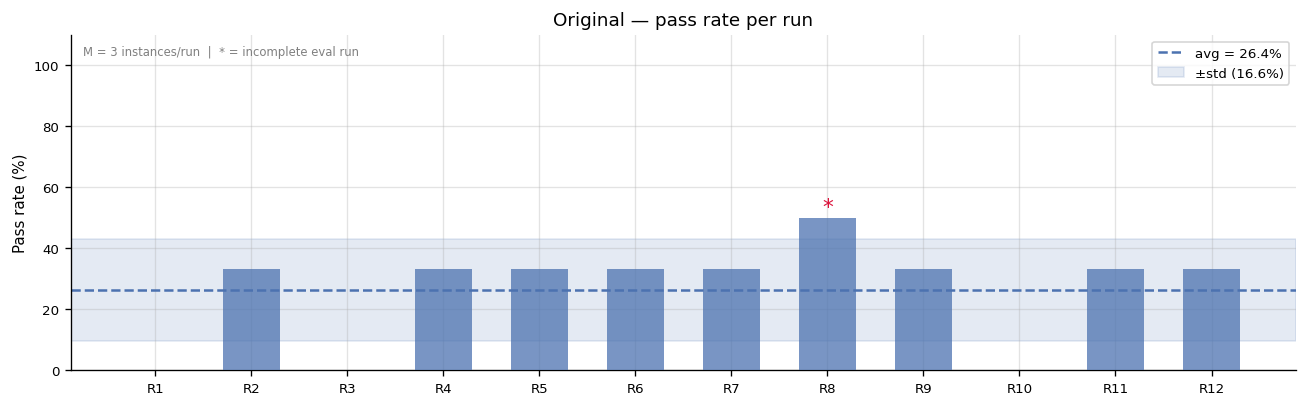

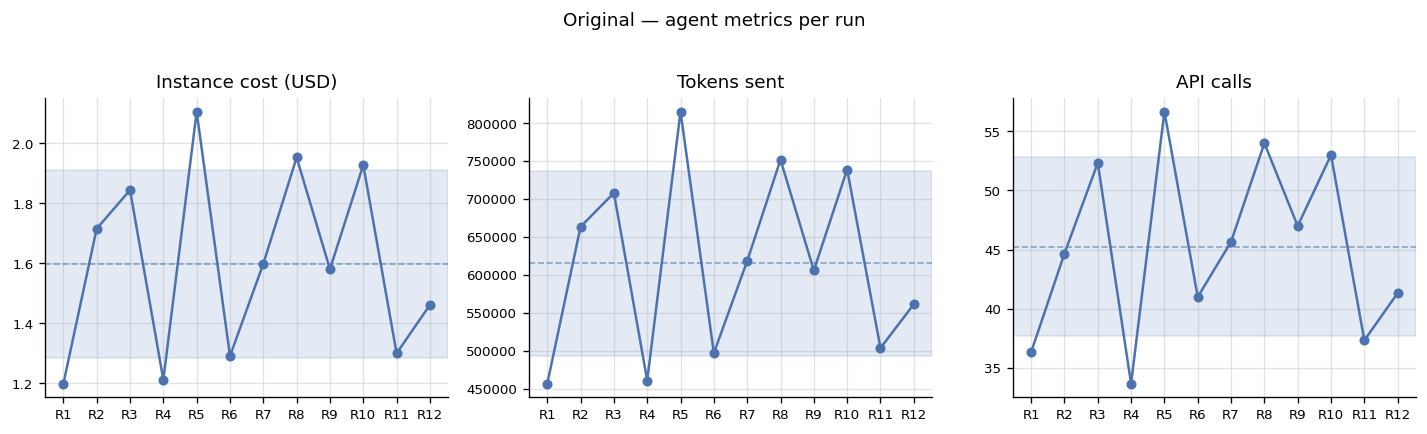

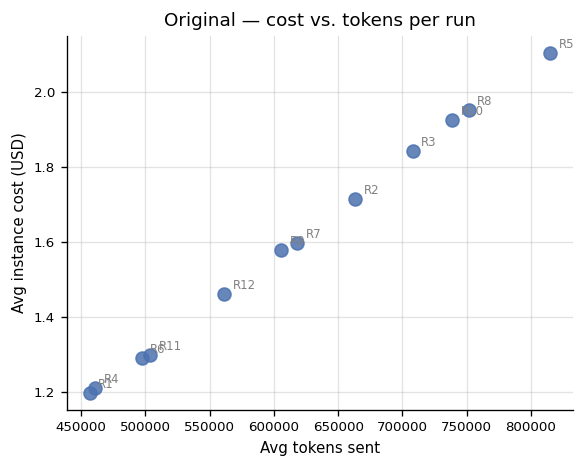


──────────────────────────────────────────────────
  Original  (12 runs × 3 instances)
──────────────────────────────────────────────────
  Pass rate        26.4 %   ± 16.6
  Instance cost  $  1.5984   (median $1.4983)
  Tokens sent       615,059   (median 575,282)
  API calls         45.2   (median 43.5)
──────────────────────────────────────────────────

  Note: M=3 instances/run → pass rate takes only discrete values
  (multiples of 33.3%). The ±std reflects discrete distribution
  spread, not measurement noise.


In [29]:
# ─── Run ──────────────────────────────────────────────────────────────────────
# Edit EVAL_DIR_A / EVAL_DIR_B / LABEL_A / LABEL_B in cell 1 above, then
# re-run this cell.  Set EVAL_DIR_B = None for a single-eval report.

if EVAL_DIR_B is None:
    build_single_report(EVAL_DIR_A, LABEL_A)
else:
    build_comparison_report(EVAL_DIR_A, LABEL_A, EVAL_DIR_B, LABEL_B)